In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb

In [71]:
df = pd.read_csv('..\\data\\segment2.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
0,48.7500,-127.75,2.906279,200.0,277.518538,299.158617,3096.673436,3222.245155
1,47.8983,-127.20,4.359262,161.0,226.597009,244.266377,3230.759601,3362.077870
2,47.8983,-127.65,3.190760,304.0,264.858297,285.511167,3125.194460,3251.988508
3,48.6833,-126.87,5.543758,60.8,200.936360,216.604786,3324.081515,3459.399294
4,48.6850,-126.87,5.543758,63.7,200.936360,216.604786,3324.081515,3459.399294


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [72]:
x = df.drop(columns=['q_ihfc','q_ps','q_stein', 'stein_z'])
y = df['q_ps']

In [73]:
x.head()

,lat,long,age,ps_z
0,48.7500,-127.75,2.906279,3096.673436
1,47.8983,-127.20,4.359262,3230.759601
2,47.8983,-127.65,3.190760,3125.194460
3,48.6833,-126.87,5.543758,3324.081515
4,48.6850,-126.87,5.543758,3324.081515


In [74]:
x.shape

(3691, 4)

In [75]:
y.head()

0    277.518538
1    226.597009
2    264.858297
3    200.936360
4    200.936360
Name: q_ps, dtype: float64

In [76]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [77]:
x_train.shape

(2952, 4)

this is the raw validation data

In [78]:
x_test.shape

(739, 4)

In [79]:
x_train.describe().round(3)

,lat,long,age,ps_z
count,2952.000,2952.000,2952.000,2952.000
mean,48.169,-128.320,1.758,2917.805
std,0.323,0.651,1.623,201.934
min,47.686,-129.505,0.009,2533.013
25%,47.879,-128.710,0.592,2769.203
50%,48.261,-128.640,0.912,2834.305
75%,48.454,-127.786,3.251,3131.081
max,48.997,-126.225,6.688,3405.155


In [80]:
x_test.describe().round(3)

,lat,long,age,ps_z
count,739.000,739.000,739.000,739.000
mean,48.179,-128.298,1.812,2920.877
std,0.322,0.684,1.712,211.911
min,47.686,-129.492,0.009,2533.013
25%,47.898,-128.710,0.592,2769.203
50%,48.340,-128.645,0.867,2825.818
75%,48.456,-127.781,3.251,3131.081
max,48.907,-126.223,6.621,3400.602


In [81]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

In [82]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':-1
}

In [83]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

In [84]:
y_pred = model.predict(x_test)

In [85]:
y_pred, y_pred.shape

(array([ 193.53843775,  615.10551967,  809.80374851,  201.18156762,
         233.32419025, 2753.36849415,  615.05749785, 5015.7851213 ,
         643.95234765,  195.84836825,  198.00506841,  615.10551967,
         254.68144099,  367.77245995,  262.39575025,  508.19579945,
         531.15935901,  437.86622136,  233.32419025,  262.39575025,
         609.45930903,  580.70762834,  394.95855459,  262.39575025,
         201.73770735,  432.95378811, 2753.73306379,  262.39575025,
        5015.7851213 ,  448.89662468,  188.87886078,  200.97012842,
         197.18782577,  209.26680731,  532.21050959,  615.10551967,
         397.63738102,  615.10551967,  209.26680731,  465.40301854,
         257.69095296,  495.23188042, 5016.51752954,  437.75795671,
         508.21948614,  264.85152745,  806.74065831,  615.10551967,
         195.22328307,  253.09561479,  250.33089063,  254.68144099,
         531.15433419, 1143.22856287,  705.90291118,  262.39575025,
         615.10440938,  615.10551967, 2754.50532

In [86]:
residuals = y_test - y_pred

negative mean: overpredicting

In [87]:
residuals.head(), residuals.describe()

(360    -0.037668
 3310   -0.001125
 1457    7.682003
 52     -0.245207
 2197    0.031925
 Name: q_ps, dtype: float64,
 count    739.000000
 mean       0.125447
 std        4.068790
 min      -17.806495
 25%       -0.033768
 50%       -0.001125
 75%        0.026477
 max       73.464051
 Name: q_ps, dtype: float64)

In [88]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [93]:
pd.DataFrame(dfr).to_csv('..\\created_data\\segment2_residuals.csv', index=False)

with open('..\\created_data\\segment2_parameters.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')

In [21]:
import matplotlib.pyplot as plt

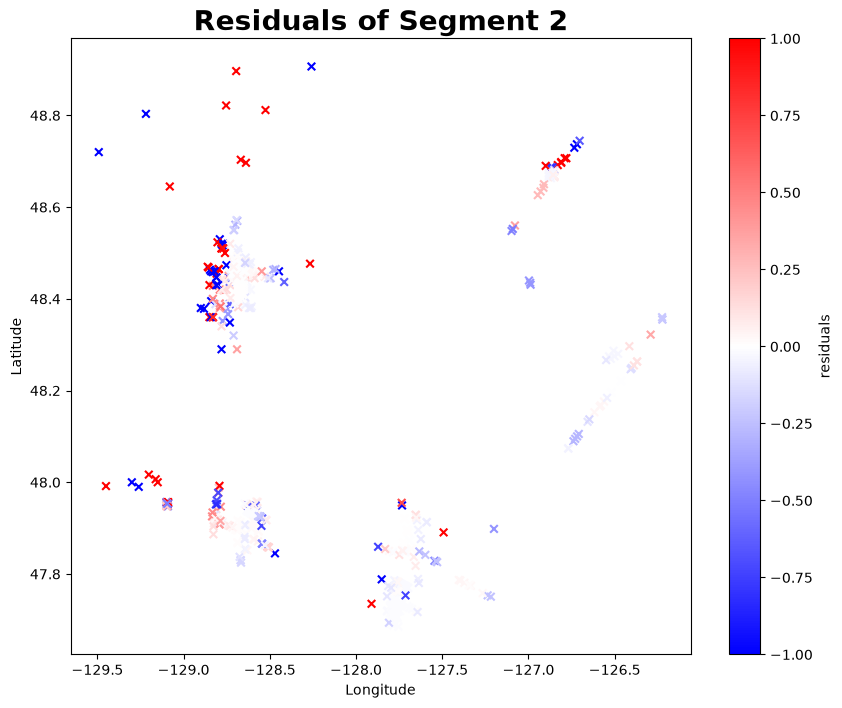

In [92]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='bwr',
            marker='x', s=30, vmin=-1, vmax=1)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Residuals of Segment 2', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\resi_seg2.png', dpi=400)
plt.show()